# Trabalho Final - Aprendizagem de Máquina

Equipe:


*   Bruno Aguiar Carneiro Silva (matr. 542562)
*   Edson Coelho Rodrigues (matr. 536038)
*   Ernesto D’Alva de Medeiros (matr. 541803)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cuml
import cupy

In [ ]:
RANDOM_STATE = 357
N_OUTER_LOOP_FOLDS = 5
N_INNER_LOOP_FOLDS = 5

## Preparação dos dados

In [ ]:
# Carregando apenas as colunas relevantes para o treino
df = pd.read_csv("creditcard_2023.csv", usecols=list(range(1,31)))

In [ ]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

## Treino e teste dos modelos


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix

def run_nested_k_fold(model, X, y, param_grid, scale_data=True, n_jobs=-1):
  # Preparando os passos do pipeline que será usado nos loops internos.
  inner_loop_steps = []
  if scale_data:
    inner_loop_steps.append(("scaler", StandardScaler()))
  inner_loop_steps.append(("classifier", model))

  # Ajustando o param_grid para o Grid Search que representará os loops internos.
  new_param_grid = param_grid.copy()
  for key in param_grid:
    new_param_grid[f"classifier__{key}"] = new_param_grid.pop(key)

  # Executando os loops externos.
  outer_cv = StratifiedKFold(
    n_splits=N_OUTER_LOOP_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
  )

  results = {
    "test_accuracy": [],
    "test_f1": [],
    "test_precision": [],
    "test_recall": [],
    "confusion_matrices": []
  }

  for train_indices, test_indices in outer_cv.split(X, y):
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # Configurando o Grid Search que representará os loops internos.
    grid_search_inner = GridSearchCV(
      estimator=Pipeline(inner_loop_steps),
      param_grid=new_param_grid,
      cv=StratifiedKFold(
        n_splits=N_INNER_LOOP_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE
      ),
      scoring="accuracy",
      verbose=1,
      n_jobs=n_jobs
    )

    grid_search_inner.fit(X_train, y_train)
    y_pred = grid_search_inner.predict(X_test)

    # Cálculo das Métricas
    results["test_accuracy"].append(accuracy_score(y_test, y_pred))
    results["test_f1"].append(f1_score(y_test, y_pred, average='binary'))
    results["test_precision"].append(precision_score(y_test, y_pred, average='binary'))
    results["test_recall"].append(recall_score(y_test, y_pred, average='binary'))
    results["confusion_matrices"].append(confusion_matrix(y_test, y_pred))

  # Converte listas para numpy arrays para usar com o sklearn.
  for key in results:
    results[key] = np.array(results[key])

  return results

### Regressão Logística (SGD)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits

--- Relatório Final do SGDClassifier ---


Acurácia: 0.9612 ± 0.0008
Revocação: 0.9393 ± 0.0030
Precisão: 0.9823 ± 0.0025
F1-score: 0.9603 ± 0.0009


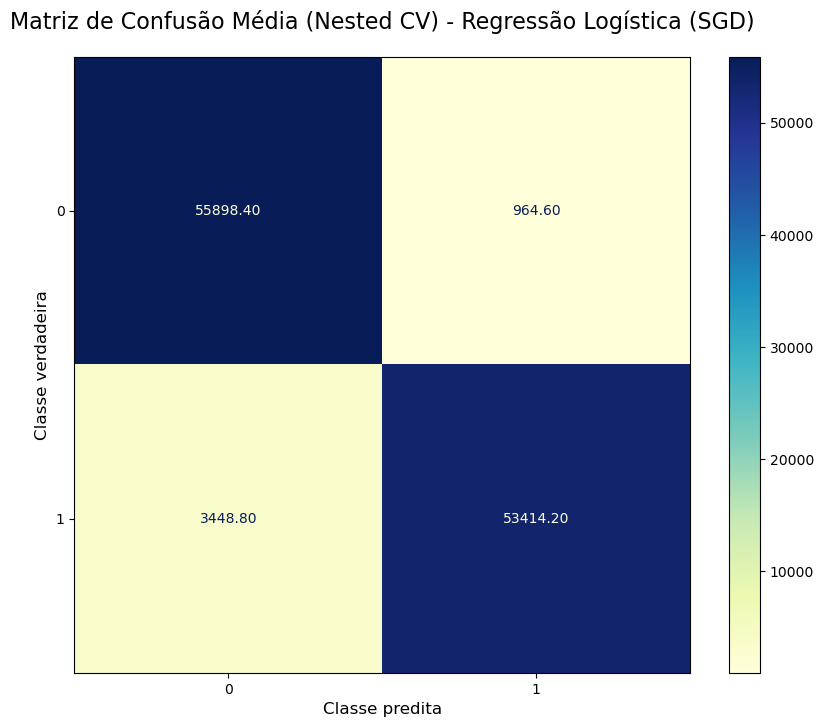

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    random_state=357,
    loss="log_loss",
    learning_rate="constant",
    penalty="l2"
)

sgd_param_grid = {
    "eta0": [1e-2, 1e-3, 1e-4],
    "alpha": [1e-3, 1e-2, 1e-1, 1.0],
}

sgd_metrics = run_nested_k_fold(
  model=sgd_model,
  X=X,
  y=y,
  param_grid=sgd_param_grid,
  scale_data=True,
  n_jobs=-1
)

print("\n--- Relatório Final do SGDClassifier ---\n")

print(f"\nAcurácia: {np.mean(sgd_metrics["test_accuracy"]):.4f} ± {np.std(sgd_metrics["test_accuracy"]):.4f}")
print(f"Revocação: {np.mean(sgd_metrics["test_recall"]):.4f} ± {np.std(sgd_metrics["test_recall"]):.4f}")
print(f"Precisão: {np.mean(sgd_metrics["test_precision"]):.4f} ± {np.std(sgd_metrics["test_precision"]):.4f}")
print(f"F1-score: {np.mean(sgd_metrics["test_f1"]):.4f} ± {np.std(sgd_metrics["test_f1"]):.4f}")

sgd_mean_cm = np.mean(sgd_metrics['confusion_matrices'], axis=0)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=sgd_mean_cm)
disp.plot(
    ax=ax,
    cmap='YlGnBu',
    values_format='.2f',
    colorbar=True
)
ax.set_title("Matriz de Confusão Média (Nested CV) - Regressão Logística (SGD)", fontsize=16, pad=20)
plt.xlabel('Classe predita', fontsize=12)
plt.ylabel('Classe verdadeira', fontsize=12)
plt.show()

### Naive Bayes Gaussiano

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits

--- Relatório Final do Naive Bayes Gaussiano ---

Acurácia: 0.9163 ± 0.0011
Revocação: 0.8487 ± 0.0018
Precisão: 0.9814 ± 0.0007
F1-score: 0.9102 ± 0.0013


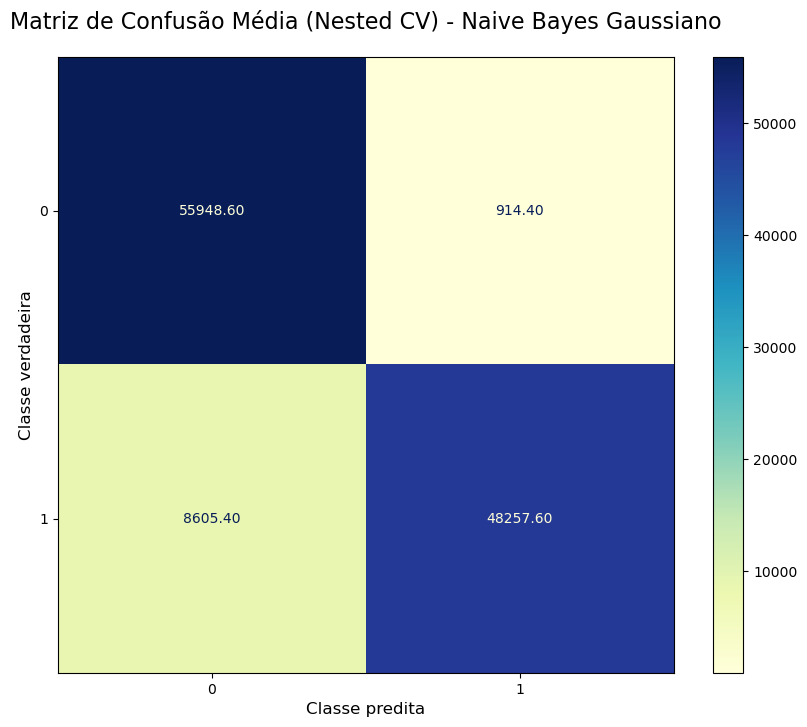

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_metrics = run_nested_k_fold(
  model=nb_model,
  X=X,
  y=y,
  param_grid={},
  scale_data=False,
  n_jobs=-1
)

print("\n--- Relatório Final do Naive Bayes Gaussiano ---\n")

print(f"Acurácia: {np.mean(nb_metrics["test_accuracy"]):.4f} ± {np.std(nb_metrics["test_accuracy"]):.4f}")
print(f"Revocação: {np.mean(nb_metrics["test_recall"]):.4f} ± {np.std(nb_metrics["test_recall"]):.4f}")
print(f"Precisão: {np.mean(nb_metrics["test_precision"]):.4f} ± {np.std(nb_metrics["test_precision"]):.4f}")
print(f"F1-score: {np.mean(nb_metrics["test_f1"]):.4f} ± {np.std(nb_metrics["test_f1"]):.4f}")

nb_mean_cm = np.mean(nb_metrics['confusion_matrices'], axis=0)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=nb_mean_cm)
disp.plot(
    ax=ax,
    cmap='YlGnBu',
    values_format='.2f',
    colorbar=True
)
ax.set_title("Matriz de Confusão Média (Nested CV) - Naive Bayes Gaussiano", fontsize=16, pad=20)
plt.xlabel('Classe predita', fontsize=12)
plt.ylabel('Classe verdadeira', fontsize=12)
plt.show()

### Support Vector Machine (SVM)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits

--- Relatório Final do Support Vector Machine (SVM) ---

Acurácia: 0.9999 ± 0.0000
Revocação: 1.0000 ± 0.0000
Precisão: 0.9998 ± 0.0000
F1-score: 0.9999 ± 0.0000


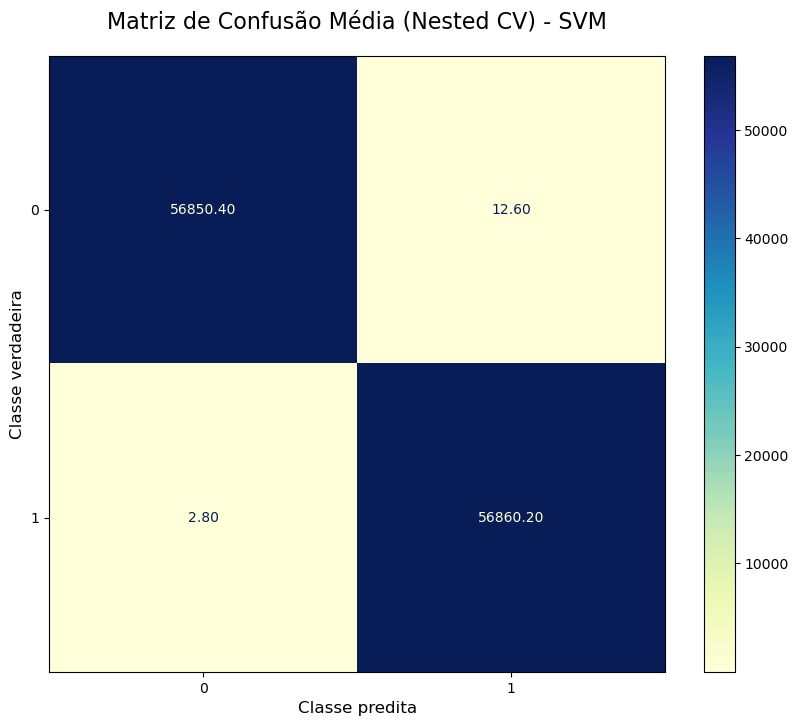

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from cuml.svm import SVC

svc_model = SVC(random_state=357)

svc_param_grid = {
  'C': [0.1, 1, 10, 100],
  'gamma': [1, 0.1, 0.01, 0.001]
}

svc_metrics = run_nested_k_fold(
  model=svc_model,
  X=X,
  y=y,
  param_grid=svc_param_grid,
  scale_data=True,
  n_jobs=1
)

print("\n--- Relatório Final do Support Vector Machine (SVM) ---\n")

print(f"Acurácia: {np.mean(svc_metrics["test_accuracy"]):.4f} ± {np.std(svc_metrics["test_accuracy"]):.4f}")
print(f"Revocação: {np.mean(svc_metrics["test_recall"]):.4f} ± {np.std(svc_metrics["test_recall"]):.4f}")
print(f"Precisão: {np.mean(svc_metrics["test_precision"]):.4f} ± {np.std(svc_metrics["test_precision"]):.4f}")
print(f"F1-score: {np.mean(svc_metrics["test_f1"]):.4f} ± {np.std(svc_metrics["test_f1"]):.4f}")

svc_mean_cm = np.mean(svc_metrics['confusion_matrices'], axis=0)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=svc_mean_cm)
disp.plot(
    ax=ax,
    cmap='YlGnBu',
    values_format='.2f',
    colorbar=True
)
ax.set_title("Matriz de Confusão Média (Nested CV) - SVM", fontsize=16, pad=20)
plt.xlabel('Classe predita', fontsize=12)
plt.ylabel('Classe verdadeira', fontsize=12)
plt.show()